download dataset

In [1]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128


In [2]:
from torchvision import datasets

dataset = datasets.OxfordIIITPet(
    root="/content/data",
    split="trainval",
    target_types="segmentation",
    download=True
)

print("Number of samples:", len(dataset))

100%|██████████| 792M/792M [00:30<00:00, 26.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.6MB/s]


Number of samples: 3680


In [3]:
import numpy as np
import torch

image, mask = dataset[0]

print("Image:", image.size)
print("Mask:", mask.size)
mask_tensor = torch.tensor(np.array(mask), dtype=torch.long)
print("Mask values:", mask_tensor.unique())

Image: (394, 500)
Mask: (394, 500)
Mask values: tensor([1, 2, 3])


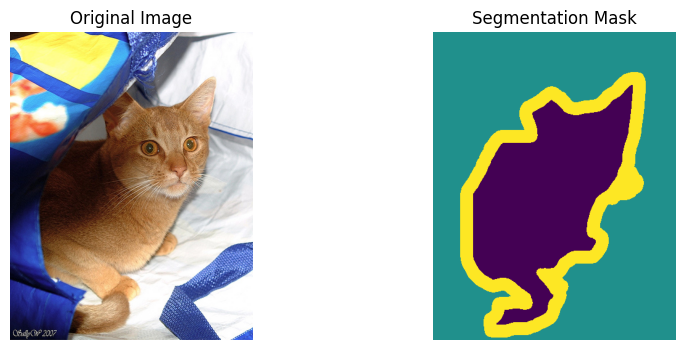

In [4]:
import matplotlib.pyplot as plt

image, mask = dataset[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

In [5]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode

image_transform = transforms.Compose([
    transforms.Resize(
        (256, 256),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    transforms.Resize(
        (256, 256),
        interpolation=InterpolationMode.NEAREST
    )
])

In [6]:
import numpy as np
import torch
from torch.utils.data import Dataset

class PetSegmentationDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        image = image_transform(image)
        mask = mask_transform(mask)

        mask = np.array(mask)

        # Pet = 1
        # Background + boundary = 0
        mask = (mask == 1).astype(np.float32)

        mask = torch.from_numpy(mask)

        return image, mask

In [7]:
train_dataset = PetSegmentationDataset(dataset)

image, mask = train_dataset[0]

print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask values:", mask.unique())

Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Mask values: tensor([0., 1.])


In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: torch.Size([16, 3, 256, 256])
Masks shape: torch.Size([16, 256, 256])


In [9]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        # Final output: 1 channel = binary segmentation
        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder + skip connections
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out(d1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet().to(device)

print(model)
print("Device:", device)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (enc4): DoubleConv(
    (block): Sequential(
      (0): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(5

In [10]:
images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

outputs = model(images)

print("Input:", images.shape)
print("Mask:", masks.shape)
print("Output:", outputs.shape)

Input: torch.Size([16, 3, 256, 256])
Mask: torch.Size([16, 256, 256])
Output: torch.Size([16, 1, 256, 256])


In [11]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss:", criterion)
print("Optimizer:", optimizer)

Loss: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [12]:
def dice_loss(outputs, masks, smooth=1.0):
    predictions = torch.sigmoid(outputs)

    predictions = predictions.view(-1)
    masks = masks.view(-1)

    intersection = (predictions * masks).sum()

    dice = (2.0 * intersection + smooth) / (
        predictions.sum() + masks.sum() + smooth
    )

    return 1 - dice


# Test
loss = dice_loss(outputs, masks)

print("Dice Loss:", loss.item())

Dice Loss: 0.5859684944152832


In [13]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        bce = criterion(outputs, masks.unsqueeze(1))
        dice = dice_loss(outputs, masks)

        loss = bce + dice

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/5] Loss: 1.2047
Epoch [2/5] Loss: 0.9400
Epoch [3/5] Loss: 0.8325
Epoch [4/5] Loss: 0.7798
Epoch [5/5] Loss: 0.7074


In [ ]:
import torch

model.eval()

total_dice = 0.0
total_iou = 0.0
num_batches = 0

with torch.no_grad():

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()
        predictions = predictions.squeeze(1)

        # Dice
        intersection = (predictions * masks).sum(dim=(1, 2))
        dice = (
            (2 * intersection + 1e-7) /
            (predictions.sum(dim=(1, 2)) + masks.sum(dim=(1, 2)) + 1e-7)
        )

        # IoU
        union = (
            predictions.sum(dim=(1, 2))
            + masks.sum(dim=(1, 2))
            - intersection
        )

        iou = (intersection + 1e-7) / (union + 1e-7)

        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        num_batches += 1

print(f"Dice: {total_dice / num_batches:.4f}")
print(f"IoU:  {total_iou / num_batches:.4f}")

In [17]:
from torch.utils.data import random_split, DataLoader

# Split trainval dataset
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# DataLoaders
train_loader = DataLoader(
    train_subset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_subset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))

Training samples: 2944
Validation samples: 736


In [18]:
import torch

epochs = 5

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        bce = criterion(outputs, masks.unsqueeze(1))
        dice = dice_loss(outputs, masks)
        loss = bce + dice

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}")

Epoch [1/5] - Train Loss: 0.6392
Epoch [2/5] - Train Loss: 0.6016
Epoch [3/5] - Train Loss: 0.5640
Epoch [4/5] - Train Loss: 0.5180
Epoch [5/5] - Train Loss: 0.4848


In [19]:
model.eval()

total_dice = 0.0
total_iou = 0.0
num_batches = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()
        predictions = predictions.squeeze(1)

        # Dice
        intersection = (predictions * masks).sum(dim=(1, 2))

        dice = (
            (2 * intersection + 1e-7) /
            (predictions.sum(dim=(1, 2)) +
             masks.sum(dim=(1, 2)) + 1e-7)
        )

        # IoU
        union = (
            predictions.sum(dim=(1, 2)) +
            masks.sum(dim=(1, 2)) -
            intersection
        )

        iou = (intersection + 1e-7) / (union + 1e-7)

        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        num_batches += 1

val_dice = total_dice / num_batches
val_iou = total_iou / num_batches

print(f"Validation Dice: {val_dice:.4f}")
print(f"Validation IoU:  {val_iou:.4f}")

Validation Dice: 0.7877
Validation IoU:  0.6699


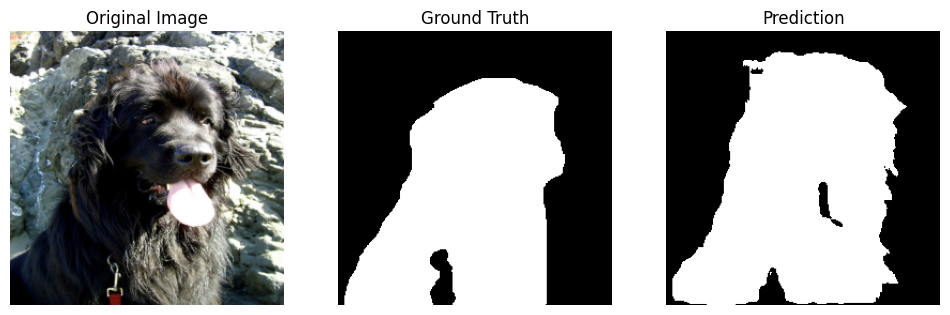

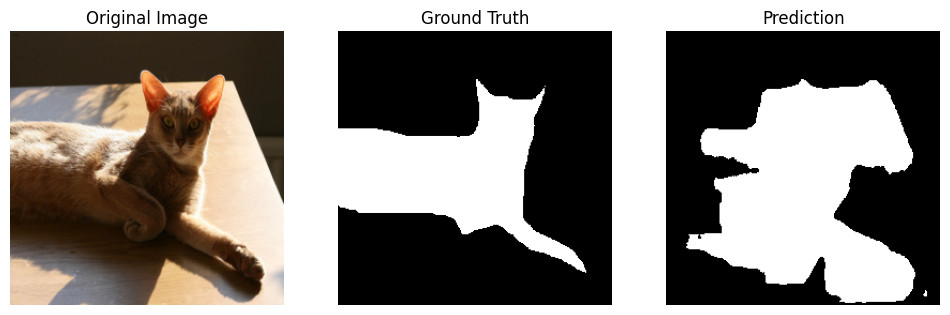

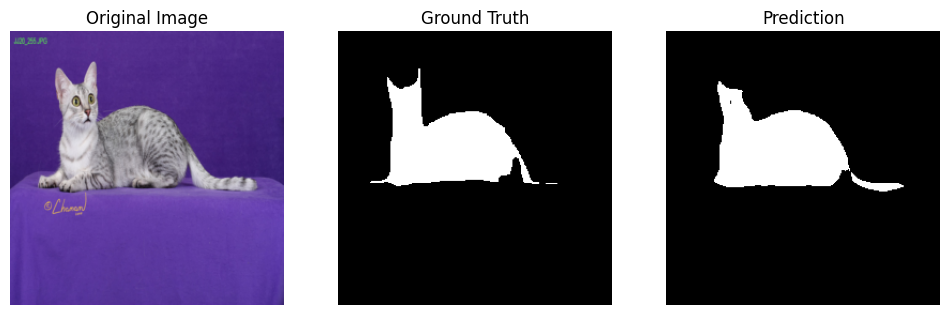

In [20]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = (torch.sigmoid(outputs) > 0.5).float()

# Show 3 examples
for i in range(3):

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(images[i].cpu().permute(1, 2, 0))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(masks[i].cpu(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predictions[i].cpu().squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

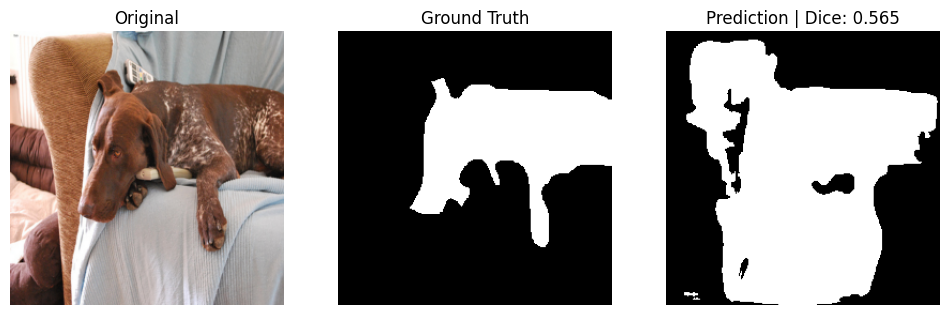

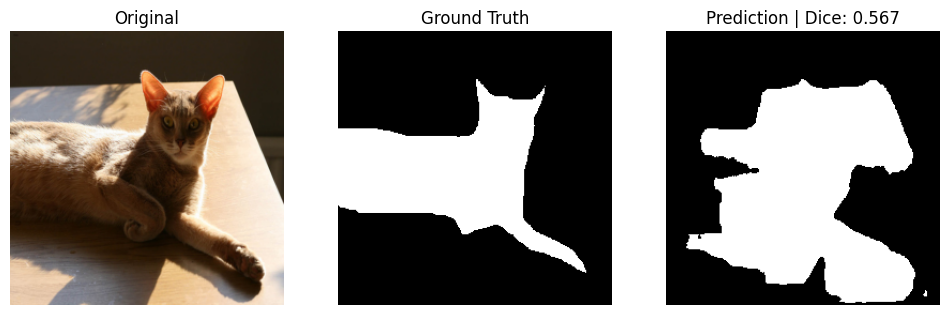

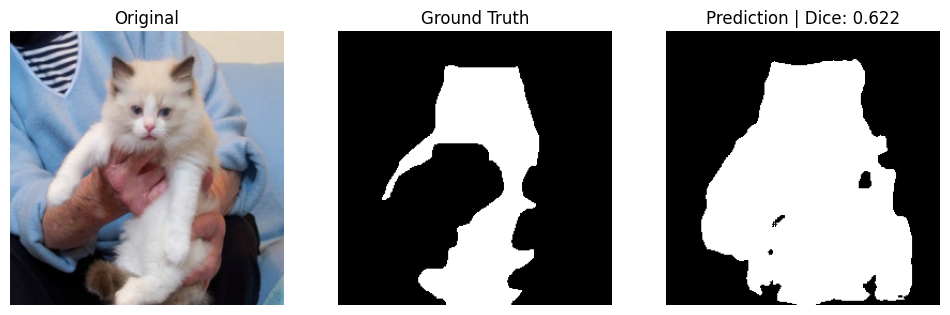

In [21]:
import matplotlib.pyplot as plt
import torch

model.eval()

images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    predictions = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)

# Dice score for each image
intersection = (predictions * masks).sum(dim=(1, 2))

dice_scores = (
    (2 * intersection + 1e-7) /
    (
        predictions.sum(dim=(1, 2))
        + masks.sum(dim=(1, 2))
        + 1e-7
    )
)

# Get 3 worst predictions
worst_indices = torch.argsort(dice_scores)[:3]

for idx in worst_indices:

    idx = idx.item()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(images[idx].cpu().permute(1, 2, 0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(masks[idx].cpu(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predictions[idx].cpu(), cmap="gray")
    plt.title(f"Prediction | Dice: {dice_scores[idx].item():.3f}")
    plt.axis("off")

    plt.show()

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

model_bce = UNet().to(device)

criterion_bce = nn.BCEWithLogitsLoss()
optimizer_bce = optim.Adam(model_bce.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):

    model_bce.train()
    train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer_bce.zero_grad()

        outputs = model_bce(images)

        loss = criterion_bce(outputs, masks.unsqueeze(1))

        loss.backward()
        optimizer_bce.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"BCE Train Loss: {train_loss:.4f}"
    )

# Validation
model_bce.eval()

total_dice = 0.0
total_iou = 0.0
num_batches = 0

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model_bce(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)

        intersection = (predictions * masks).sum(dim=(1, 2))

        dice = (
            (2 * intersection + 1e-7) /
            (
                predictions.sum(dim=(1, 2))
                + masks.sum(dim=(1, 2))
                + 1e-7
            )
        )

        union = (
            predictions.sum(dim=(1, 2))
            + masks.sum(dim=(1, 2))
            - intersection
        )

        iou = (intersection + 1e-7) / (union + 1e-7)

        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        num_batches += 1

bce_dice = total_dice / num_batches
bce_iou = total_iou / num_batches

print(f"\nBCE-only Validation Dice: {bce_dice:.4f}")
print(f"BCE-only Validation IoU:  {bce_iou:.4f}")

Epoch [1/5] BCE Train Loss: 0.6123
Epoch [2/5] BCE Train Loss: 0.6017
Epoch [3/5] BCE Train Loss: 0.5508
Epoch [4/5] BCE Train Loss: 0.5321
Epoch [5/5] BCE Train Loss: 0.5218

BCE-only Validation Dice: 0.0383
BCE-only Validation IoU:  0.0224


In [23]:
import random
from torchvision import transforms
from torchvision.transforms import InterpolationMode

Augmented dataset ready


In [26]:
class AugmentedPetSegmentationDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        if random.random() > 0.5:
            image = transforms.functional.hflip(image)
            mask = transforms.functional.hflip(mask)

        if random.random() > 0.5:
            image = transforms.functional.vflip(image)
            mask = transforms.functional.vflip(mask)

        image = transforms.functional.resize(
            image, (256, 256),
            interpolation=InterpolationMode.BILINEAR
        )

        mask = transforms.functional.resize(
            mask, (256, 256),
            interpolation=InterpolationMode.NEAREST
        )

        mask = np.array(mask)
        mask = (mask == 1).astype(np.float32)
        mask = torch.from_numpy(mask)

        return image, mask

aug_dataset = AugmentedPetSegmentationDataset(train_subset)

aug_train_loader = DataLoader(
    aug_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

print("Augmented dataset ready")
print("Samples:", len(aug_dataset))
print("Batches:", len(aug_train_loader))

Augmented dataset ready
Samples: 2944
Batches: 184


In [27]:
aug_train_loader = DataLoader(
    aug_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

print("Augmented train samples:", len(aug_dataset))
print("Batches per epoch:", len(aug_train_loader))

Augmented train samples: 2944
Batches per epoch: 184


In [28]:
model_aug = UNet().to(device)

criterion_aug = nn.BCEWithLogitsLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model_aug.train()
    train_loss = 0.0

    for images, masks in aug_train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer_aug.zero_grad()

        outputs = model_aug(images)

        bce = criterion_aug(outputs, masks.unsqueeze(1))
        dice = dice_loss(outputs, masks)

        loss = bce + dice

        loss.backward()
        optimizer_aug.step()

        train_loss += loss.item()

    train_loss /= len(aug_train_loader)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Augmented Train Loss: {train_loss:.4f}"
    )

/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)
/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)


Epoch [1/5] Augmented Train Loss: 1.2593


/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)
/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)


Epoch [2/5] Augmented Train Loss: 1.3124


/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)
/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)


Epoch [3/5] Augmented Train Loss: 1.0350


/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)
/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)


Epoch [4/5] Augmented Train Loss: 0.8880


/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)
/tmp/ipykernel_1628/1909357459.py:29: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  mask = np.array(mask)


Epoch [5/5] Augmented Train Loss: 0.8659


In [29]:
model_aug.eval()

total_dice = 0.0
total_iou = 0.0
num_batches = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model_aug(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)

        intersection = (predictions * masks).sum(dim=(1, 2))

        dice = (
            (2 * intersection + 1e-7)
            / (predictions.sum(dim=(1, 2)) + masks.sum(dim=(1, 2)) + 1e-7)
        )

        union = (
            predictions.sum(dim=(1, 2))
            + masks.sum(dim=(1, 2))
            - intersection
        )

        iou = (intersection + 1e-7) / (union + 1e-7)

        total_dice += dice.mean().item()
        total_iou += iou.mean().item()
        num_batches += 1

aug_dice = total_dice / num_batches
aug_iou = total_iou / num_batches

print(f"Augmented U-Net Validation Dice: {aug_dice:.4f}")
print(f"Augmented U-Net Validation IoU: {aug_iou:.4f}")

Augmented U-Net Validation Dice: 0.6571
Augmented U-Net Validation IoU: 0.5057


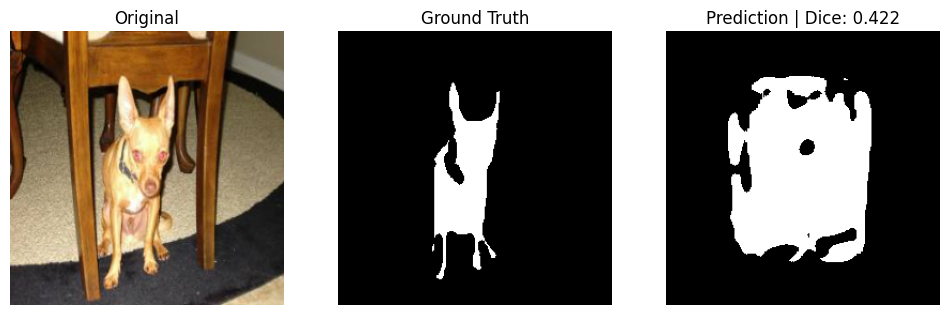

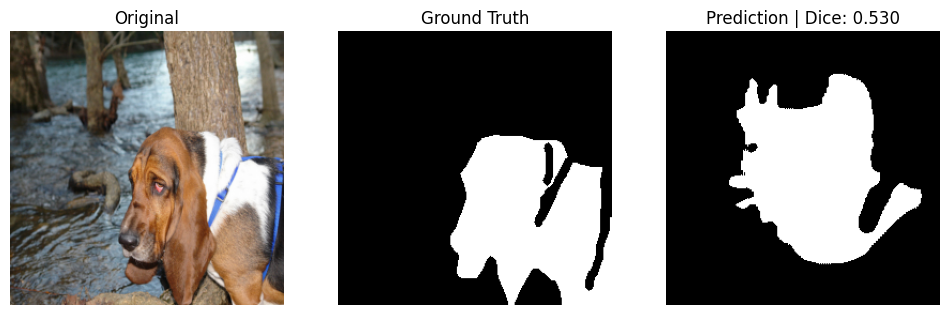

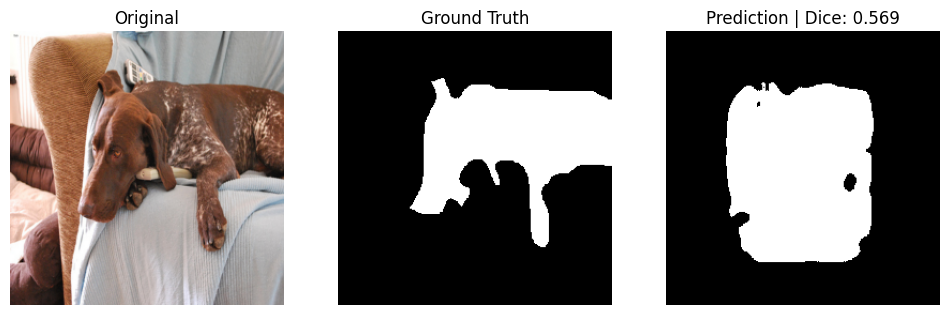

In [30]:
import matplotlib.pyplot as plt
import torch

model_aug.eval()

images, masks = next(iter(val_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model_aug(images)
    predictions = (torch.sigmoid(outputs) > 0.5).float().squeeze(1)

intersection = (predictions * masks).sum(dim=(1, 2))

dice_scores = (
    (2 * intersection + 1e-7)
    / (
        predictions.sum(dim=(1, 2))
        + masks.sum(dim=(1, 2))
        + 1e-7
    )
)

worst_indices = torch.argsort(dice_scores)[:3]

for idx in worst_indices:
    idx = idx.item()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(images[idx].cpu().permute(1, 2, 0))
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(masks[idx].cpu(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predictions[idx].cpu(), cmap="gray")
    plt.title(f"Prediction | Dice: {dice_scores[idx].item():.3f}")
    plt.axis("off")

    plt.show()

In [31]:
torch.save(
    model_aug.state_dict(),
    "/content/unet_augmented_best.pth"
)

print("Model saved successfully:")
print("/content/unet_augmented_best.pth")

Model saved successfully:
/content/unet_augmented_best.pth
